In [1]:
import os
import pickle as pkl

KG_IDX = 2
kg_file = "data/dataset/5_error/encoded/test_5_error.pkl"
with open(kg_file, "rb") as f:
    dataset, _ = pkl.load(f)


In [2]:
len(dataset)


2000

In [3]:
docs[KG_IDX]

'continuity [12] I stuck the end of my cigarette into the roaring brazier near my table. A long drag filled my lungs with sweet nicotine, and relief flooded through my muscles. It had been damn near two days since I\'d had a cigarette; there was just the one pack in my pocket when I found myself here, and I had to make it last. Nowhere in this world seemed to carry my brand, after all. Or even have cigarettes in the first place. Sorcerors, giants, ogres, potions, magic... sure. But no cigarettes. Just my luck, I guess. "Excuse me?" A voice asked, barely loud enough to be heard over the roaring din of the tavern. "Are you... are you the Man in Black?" I looked down at my suit. It was not pinstriped, but no one in this world seemed to know what that was. Everyone here wore heavy robes and wolf furs and crap like that. And not a single man had the decency to wear a proper hat, or a tie. "I suppose I am," I answered, tipping the brim of my trilby back to get a good look at him and gulping 

In [37]:
print(kg[KG_IDX]["edge_indices"])

tensor([[  1,   1,   4,   4,   1,   1,   4,   4,   1,   4,   8,   9,  11,   1,
           1,  14,   1,  17,   1,   1,  17,  21,  21,  24,  24,  23,   1,  28,
          28,  28,  32,  32,  32,  32,  37,  37,  37,  41,   1,   1,   1,  24,
          24,  48,  24,  24,  24,   1,   1,   1,   1,   1,  55,  17,   1,  17,
          17,  17,   1,   1,  62,  64,  24,  24,  24,   1,  37,  69,  71,  71,
          71,  71,  71,  71,  71,  78,  67,   1,   1,  83,   1,  83,   1,   1,
           1,   1,   1,   1,   1,  94,  94,  93,  96,  96,  96,  96,  15,  27,
         103, 103,  37, 106,  52,  94,  15,  27,   1],
        [  0,   2,   3,   5,   6,   5,   2,   6,   3,   0,   7,   7,  10,  12,
          12,  13,  15,  16,  18,  15,  19,  20,  22,  23,  25,  25,  26,  27,
          29,  30,  31,  33,  34,  35,  36,  38,  39,  40,  42,  43,  44,  45,
          46,  47,  49,  50,  51,  52,  52,  52,  52,  53,  54,  56,  12,  57,
          58,  59,  60,  61,  36,  63,  36,  65,  66,  53,  67,  68,  70,  7

In [38]:
import networkx as nx
node_labels = kg[KG_IDX]["node_labels"]
edge_labels = kg[KG_IDX]["edge_labels"]
# TODO add labels nodes and edges from openie subject/object/relations
def create_graph_from_edge_indices(edge_indices):
    edges = zip(*edge_indices)
    graph = nx.Graph()
    #graph.add_nodes_from(node_labels)
    graph.add_edges_from(edges)#, label=edge_labels)
    print(len(node_labels))
    return graph

edge_indices = kg[KG_IDX]["edge_indices"].numpy().tolist()
graph = create_graph_from_edge_indices(edge_indices)

111


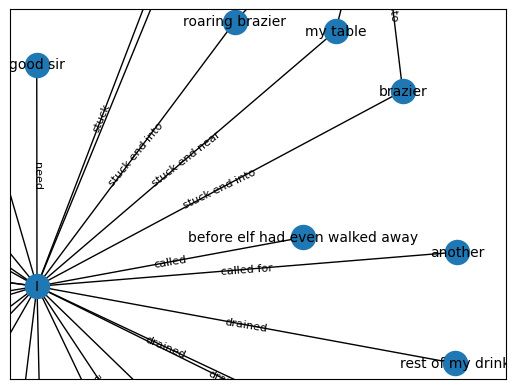

In [103]:
import matplotlib.pyplot as plt
import random


def visualize_graph(graph):
    #nx.draw(graph, with_labels=True)
    
    # Add labels
    edges = list(zip(*edge_indices))
    pos = nx.spring_layout(graph, seed=0)
    node_labels_dict = { i: node_labels[i] for i in range(len(node_labels)) }
    edge_labels_dict = { (edges[i][0], edges[i][1]): edge_labels[i] for i in range(len(edge_labels)) }
    #labels = {1: 'Node 1', 2: 'Node 2', 3: 'Node 3'}
    #edge_labels = {(1, 2): 'Edge 1-2', (1, 3): 'Edge 1-3', (2, 3): 'Edge 2-3'}
    nx.draw_networkx_labels(graph, pos, node_labels_dict, font_size=10)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels_dict, font_size=8)
    nx.draw_networkx_nodes(graph, pos)
    nx.draw_networkx_edges(graph, pos)

    plt.xlim(0.19, 0.29)  # Set x-axis limits for zoom TODO fix this zoom
    plt.ylim(0.30, 0.39)  # Set y-axis limits for zoom
    plt.show()
visualize_graph(graph)

Represented sentences:

"I stuck the end of my cigarette into the roaring brazier near my table."

"My patron sipped at his booze like a bird and grimaced, while I drained mine and called for another before the elf had even walked away."

"I need your help, good sir."